In [51]:
import pandas as pd

In [52]:
import matplotlib.pyplot as plt

In [53]:
RRHH = pd.read_csv(r'C:\Users\rubit\Desktop\Formaciones\IT ACADEMY\Simulador\proyecto\ProjecteData\Data\clean_RRHH_16032026.csv')

In [54]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours,Reason_Description
0,14,11,November,Monday,Spring,155,12,14,34,284.031,97,0,High School,2,True,False,0,25,120,Digestive system diseases
1,36,13,April,Wednesday,Winter,118,13,18,50,239.409,98,0,High School,1,True,False,0,31,120,Musculoskeletal/Connective tissue
2,9,6,July,Tuesday,Summer,228,14,16,58,264.604,93,0,High School,2,False,False,1,22,120,Nervous system diseases
3,28,9,July,Tuesday,Summer,225,26,9,28,230.290,92,0,High School,1,False,False,2,24,112,Circulatory system diseases
4,9,12,March,Tuesday,Autumn,228,14,16,58,222.196,99,0,High School,2,False,False,1,22,112,Skin/Subcutaneous diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,382,22,May,Wednesday,Winter,291,31,12,40,237.656,99,0,High School,1,True,False,1,25,8,Patient follow-up
1052,383,23,July,Monday,Summer,235,29,12,48,230.290,92,0,High School,1,False,True,5,33,1,Medical consultation
1053,384,10,November,Wednesday,Spring,260,50,11,36,284.031,97,0,High School,4,True,False,0,23,8,Respiratory system diseases
1054,385,23,December,Friday,Spring,225,26,9,28,280.549,98,0,High School,1,False,False,2,24,3,Medical consultation


Dataset con el que trabajaremos:

In [55]:
df_empleados = RRHH.groupby("ID").agg({
    'Hit_target': 'mean',
    'Disciplinary_failure': 'max',
    'Distance_Residence_Work': 'max',
    'Service_time': 'max',
    'Work_load_Average_day': 'max',
}).reset_index()

In [56]:
df_empleados

,ID,Hit_target,Disciplinary_failure,Distance_Residence_Work,Service_time,Work_load_Average_day
0,1,95.173913,1,11,14,377.550
1,2,93.333333,1,29,12,326.452
2,3,94.762887,1,51,18,378.884
3,4,95.000000,0,14,13,271.219
4,5,91.722222,1,20,13,330.061
...,...,...,...,...,...,...
381,382,99.000000,0,31,12,237.656
382,383,92.000000,0,29,12,230.290
383,384,97.000000,0,50,11,284.031
384,385,98.000000,0,26,9,280.549


Rendimiento continuo (Hit_target)

In [57]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, ttest_ind

import statsmodels.api as sm
import statsmodels.formula.api as smf

Distribución de hit_target

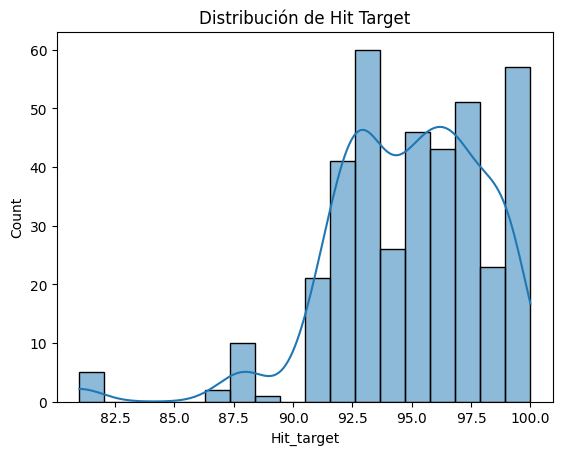

In [58]:
sns.histplot(df_empleados["Hit_target"], kde=True)
plt.title("Distribución de Hit Target")
plt.show()

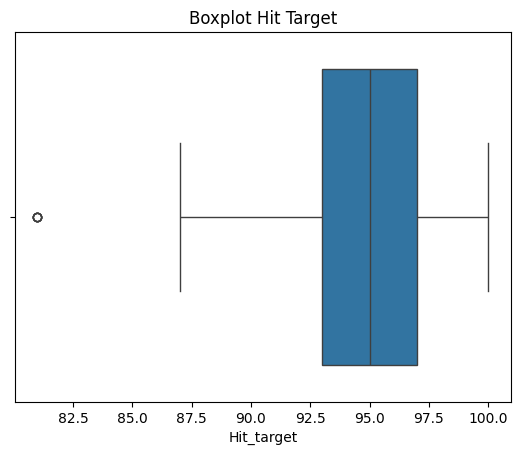

In [59]:
sns.boxplot(x=df_empleados["Hit_target"])
plt.title("Boxplot Hit Target")
plt.show()

**Visualizar relación entre variables**

Ahora vemos relaciones visuales.

Antigüedad vs rendimiento

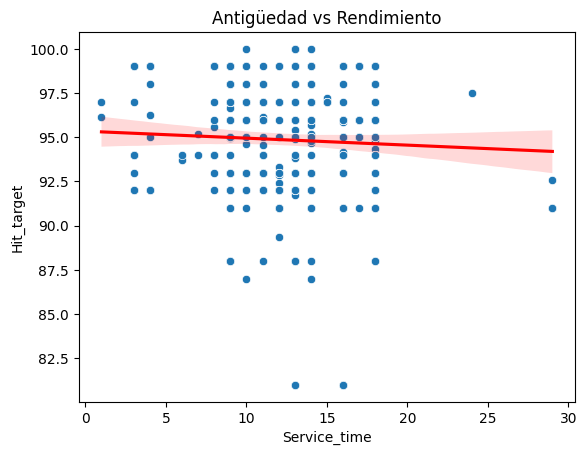

In [60]:
sns.scatterplot(
    x="Service_time",
    y="Hit_target",
    data=df_empleados
)

sns.regplot(
    x="Service_time",
    y="Hit_target",
    data=df_empleados,
    scatter=False,
    color="red"
)

plt.title("Antigüedad vs Rendimiento")
plt.show()

Carga laboral vs. Rendimiento

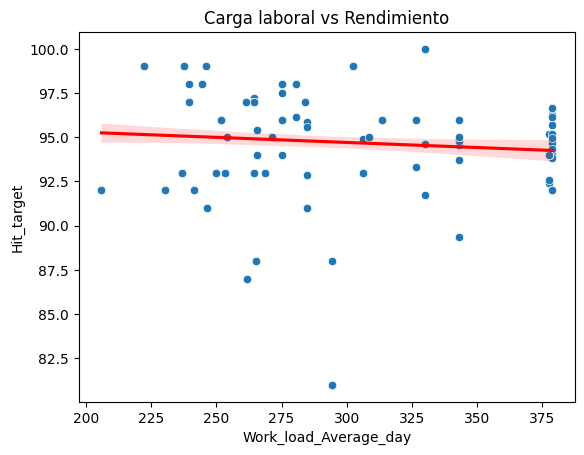

In [61]:
sns.scatterplot(
    x="Work_load_Average_day",
    y="Hit_target",
    data=df_empleados
)

sns.regplot(
    x="Work_load_Average_day",
    y="Hit_target",
    data=df_empleados,
    scatter=False,
    color="red"
)

plt.title("Carga laboral vs Rendimiento")
plt.show()

Distancia vs rendimiento

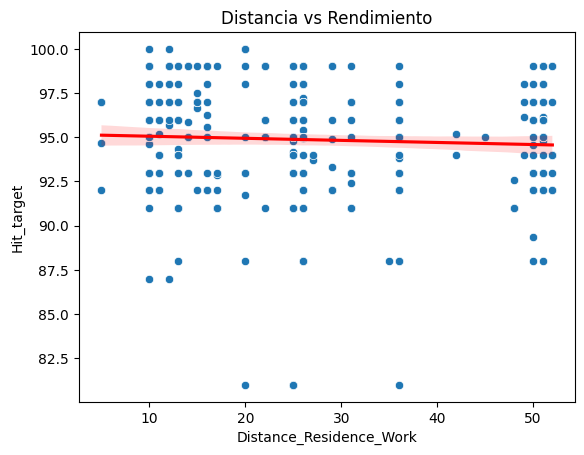

In [62]:
sns.scatterplot(
    x="Distance_Residence_Work",
    y="Hit_target",
    data=df_empleados
)

sns.regplot(
    x="Distance_Residence_Work",
    y="Hit_target",
    data=df_empleados,
    scatter=False,
    color="red"
)

plt.title("Distancia vs Rendimiento")
plt.show()

**Correlaciones estadísticas**

Ahora medimos relación estadística real.

Correlación Pearson

In [63]:
corr = df_empleados[[
    "Hit_target",
    "Service_time",
    "Work_load_Average_day",
    "Distance_Residence_Work"
]].corr()

print(corr)

                         Hit_target  Service_time  Work_load_Average_day  \
Hit_target                 1.000000     -0.051544              -0.078279   
Service_time              -0.051544      1.000000               0.002316   
Work_load_Average_day     -0.078279      0.002316               1.000000   
Distance_Residence_Work   -0.053319      0.183051              -0.012734   

                         Distance_Residence_Work  
Hit_target                             -0.053319  
Service_time                            0.183051  
Work_load_Average_day                  -0.012734  
Distance_Residence_Work                 1.000000  


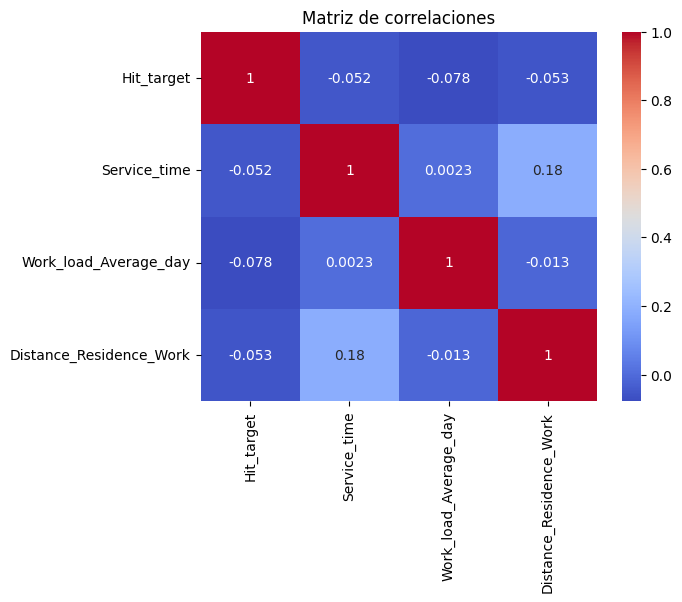

In [64]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlaciones")
plt.show()

correlación	interpretación

0.7+	fuerte

0.3 – 0.7	moderada

<0.3	débil


Correlación + p-value

In [65]:
pearsonr(df_empleados["Service_time"], df_empleados["Hit_target"])

PearsonRResult(statistic=np.float64(-0.05154414938353786), pvalue=np.float64(0.3124621838662418))

In [66]:
pearsonr(df_empleados["Work_load_Average_day"], df_empleados["Hit_target"])

PearsonRResult(statistic=np.float64(-0.0782788590551893), pvalue=np.float64(0.12470906989520185))

In [67]:
pearsonr(df_empleados["Distance_Residence_Work"], df_empleados["Hit_target"])

PearsonRResult(statistic=np.float64(-0.0533186160785433), pvalue=np.float64(0.2960735240959212))

p-value < 0.05 -- Relación estadísticamente significativa

No hay evidencia estadística de relación lineal entre estas variables y el rendimiento (Hit_target).

**Analizar disciplinas (variable booleana)**

Rendimiento(Disciplinary_failure) Booleano

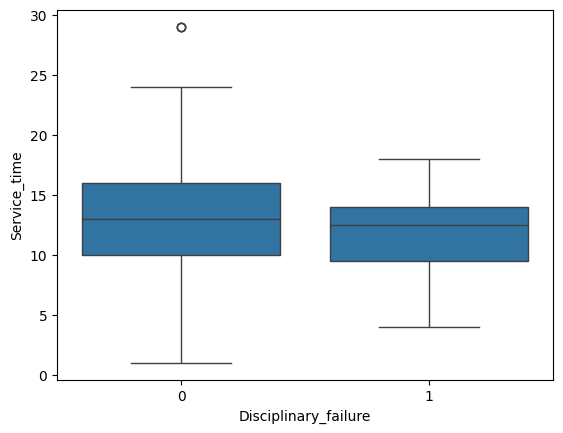

In [68]:
sns.boxplot(
    x="Disciplinary_failure",
    y="Service_time",
    data=df_empleados
)
plt.show()

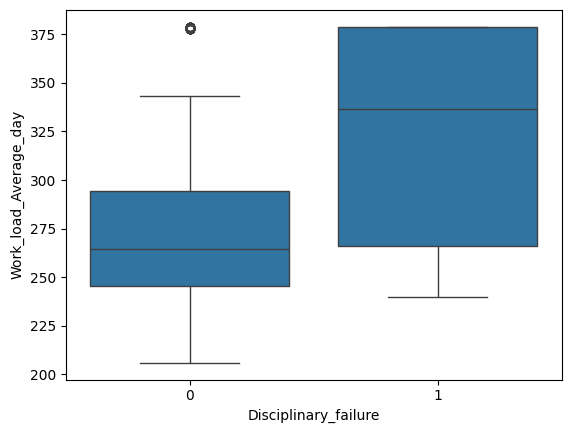

In [69]:
sns.boxplot(
    x="Disciplinary_failure",
    y="Work_load_Average_day",
    data=df_empleados
)
plt.show()

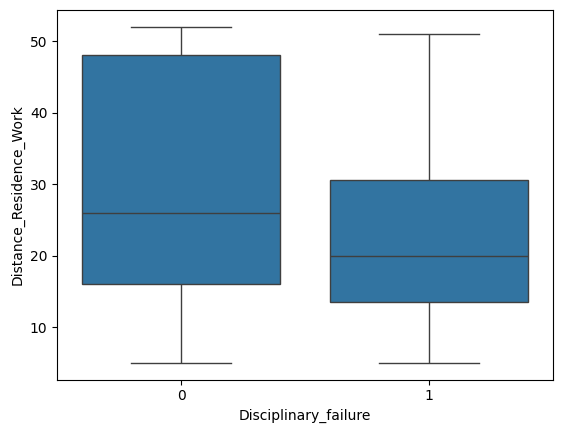

In [70]:
sns.boxplot(
    x="Disciplinary_failure",
    y="Distance_Residence_Work",
    data=df_empleados
)
plt.show()

Para confirmar si las diferencias son reales.

T-test

In [71]:
group1_work = df_empleados[df_empleados["Disciplinary_failure"] == 0]["Work_load_Average_day"]
group2_work = df_empleados[df_empleados["Disciplinary_failure"] == 1]["Work_load_Average_day"]

ttest_ind(group1_work, group2_work)

TtestResult(statistic=np.float64(-6.243755598904006), pvalue=np.float64(1.1325485301362685e-09), df=np.float64(384.0))

La carga laboral sí está asociada a fallos disciplinarios. Más carga laboral = Más probabilidad de problemas disciplinarios

In [72]:
group1_service = df_empleados[df_empleados["Disciplinary_failure"] == 0]["Service_time"]
group2_service = df_empleados[df_empleados["Disciplinary_failure"] == 1]["Service_time"]

ttest_ind(group1_service, group2_service)

TtestResult(statistic=np.float64(0.7952556696991954), pvalue=np.float64(0.42695606752618986), df=np.float64(384.0))

In [73]:
group1_distance = df_empleados[df_empleados["Disciplinary_failure"] == 0]["Distance_Residence_Work"]
group2_distance = df_empleados[df_empleados["Disciplinary_failure"] == 1]["Distance_Residence_Work"]

ttest_ind(group1_distance, group2_distance)

TtestResult(statistic=np.float64(1.8147801874351641), pvalue=np.float64(0.07033778676639792), df=np.float64(384.0))

No hay diferencias significativas

**Modelo explicativo**

Usamos regresión multiple para ver impacto conjunto

In [74]:
model = smf.ols(
    "Hit_target ~ Service_time + Work_load_Average_day + Distance_Residence_Work",
    data=df_empleados
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Hit_target   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.397
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.243
Time:                        10:14:44   Log-Likelihood:                -996.54
No. Observations:                 386   AIC:                             2001.
Df Residuals:                     382   BIC:                             2017.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

R-squared: 0.011 - El modelo explica solo 1.1% del rendimiento.- Estas variables prácticamente no explican el rendimiento.

Todas p-value > 0.05.

Ninguna variable muestra un efecto estadísticamente significativo sobre el porcentaje de cumplimiento de objetivos.

El análisis no encontró evidencia estadísticamente significativa de que la antigüedad (Service_time), la carga laboral diaria (Work_load_Average_day) o la distancia al lugar de trabajo (Distance_Residence_Work) influyan directamente en el porcentaje de cumplimiento de objetivos (Hit_target). Sin embargo, se encontró una relación significativa entre la carga laboral y los fallos disciplinarios, lo que sugiere que niveles elevados de carga laboral podrían estar asociados a problemas de comportamiento organizacional.

**Categoría de rendimiento**

¿93% o 95%?: No elijas al azar. Mira la distribución de tus datos. Si el 90% de tus empleados tiene más de 95, poner el corte en 95 te dejará con muy pocos casos de "bajo rendimiento" para analizar.

Propuesta: Usa el primer cuartil ($Q_1$). Si el 25% de los empleados está por debajo de 93, ese es un buen umbral para definir el "riesgo".

In [75]:
umbral = df_empleados['Hit_target'].quantile(0.25)
print(f"El valor del percentil 25 es: {umbral}")

El valor del percentil 25 es: 93.0


In [76]:
umbral = df_empleados['Hit_target'].quantile(0.25) 
df_empleados['Low_performance'] = (df_empleados['Hit_target'] < umbral).astype(int)

In [77]:
df_empleados

,ID,Hit_target,Disciplinary_failure,Distance_Residence_Work,Service_time,Work_load_Average_day,Low_performance
0,1,95.173913,1,11,14,377.550,0
1,2,93.333333,1,29,12,326.452,0
2,3,94.762887,1,51,18,378.884,0
3,4,95.000000,0,14,13,271.219,0
4,5,91.722222,1,20,13,330.061,1
...,...,...,...,...,...,...,...
381,382,99.000000,0,31,12,237.656,0
382,383,92.000000,0,29,12,230.290,1
383,384,97.000000,0,50,11,284.031,0
384,385,98.000000,0,26,9,280.549,0


Árbol de decisión

In [78]:
# Seleccionamos las variables
features = ['Work_load_Average_day', 'Distance_Residence_Work', 'Service_time']
X = df_empleados[features]
y = df_empleados['Low_performance']

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
from sklearn.tree import DecisionTreeClassifier

# Creamos el modelo (limitamos la profundidad para que sea fácil de leer)
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [81]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo_arbol.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[62  1]
 [13  2]]
              precision    recall  f1-score   support

           0       0.83      0.98      0.90        63
           1       0.67      0.13      0.22        15

    accuracy                           0.82        78
   macro avg       0.75      0.56      0.56        78
weighted avg       0.80      0.82      0.77        78



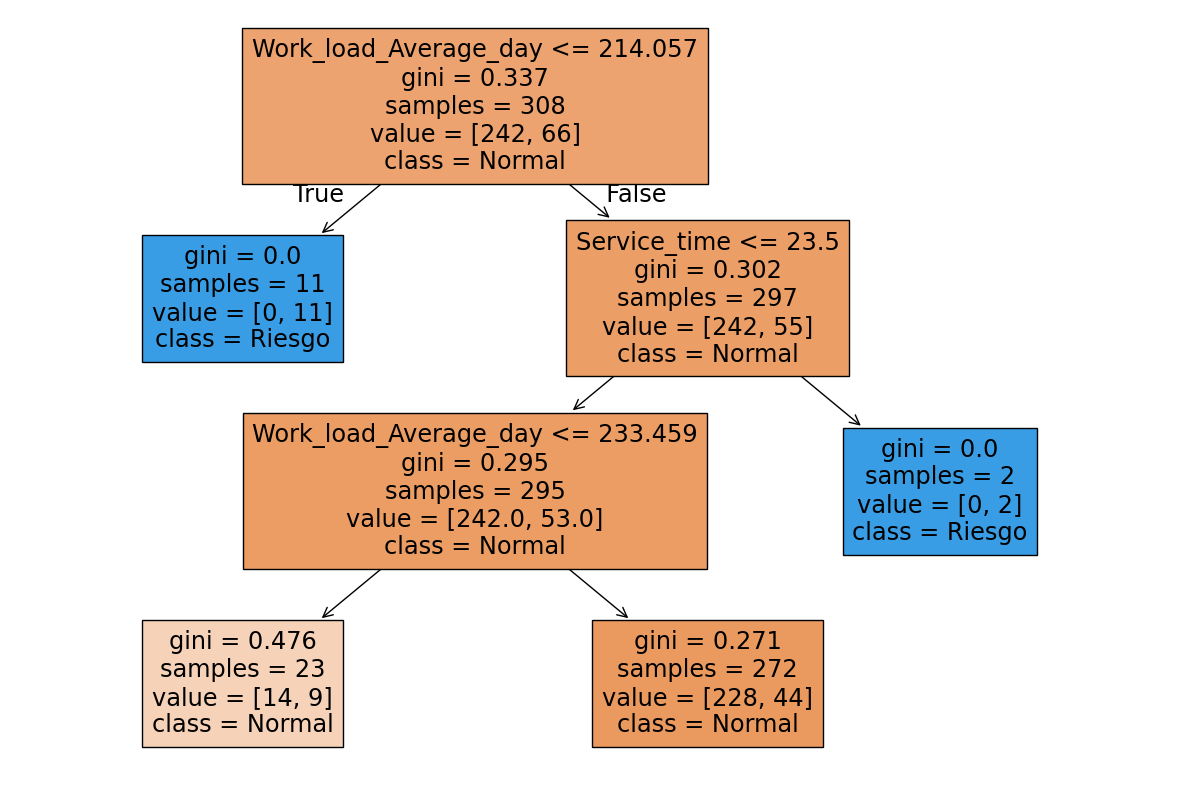

In [82]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(modelo_arbol, feature_names=features, class_names=['Normal', 'Riesgo'], filled=True)
plt.show()

El Factor Determinante: La Carga Laboral

El árbol dice que la carga laboral es la variable más importante para separar a los empleados.⚠️ Perfil de Riesgo Crítico 1: Sorprendentemente, el árbol indica que si la carga es MUY BAJA ($\le 214.057$), todos esos empleados (11 de 11 en ese nodo azul a la izquierda) caen en la categoría de Riesgo.
Interpretación: Esto sugiere que la falta de tareas o el "aburrimiento laboral" (boreout) podría estar afectando el rendimiento tanto como el exceso de trabajo.

El Factor Secundario: La Antigüedad (Service_time)Si la carga es superior a 214, pasamos al siguiente filtro: la antigüedad en la empresa.⚠️ Perfil de Riesgo Crítico 2: Empleados con carga > 214 pero con una antigüedad MUY ALTA ($> 23.5$ años).Interpretación: Los veteranos con mucha antigüedad (nodo azul a la derecha) también muestran una tendencia al bajo rendimiento. Quizás por falta de actualización o desmotivación tras tantos años.

El Perfil de Rendimiento "Normal"El grupo más grande y saludable (272 personas, nodo naranja abajo a la derecha) es aquel que:Tiene una carga equilibrada ($> 214$ pero $\le 233$).Tiene una antigüedad moderada ($\le 23.5$ años).

A. ¿Podemos identificar perfiles con mayor riesgo?"

Sí. Hemos detectado dos perfiles claros de riesgo de bajo rendimiento: 

1) Colaboradores con una carga laboral inusualmente baja ($\le 214$), lo que podría indicar infrautilización del talento, y 

2) Veteranos con más de 23 años en la empresa, quienes presentan una caída estadística en sus indicadores de rendimiento."

¿Qué ajustes podemos hacer en la organización?

Redistribución de carga: Asegurarnos de que nadie esté por debajo de los 214 puntos de carga para evitar la desmotivación por falta de tareas.

Planes de "Reskilling" para Veteranos: Crear programas específicos para los colaboradores de más de 23 años de antigüedad, como mentorías (donde ellos enseñen) o formación tecnológica para reengancharlos.

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Usamos exactamente las mismas que en tu árbol
# (Asegúrate de que los nombres coincidan con tu df)
features_tree = ['Work_load_Average_day', 'Service_time', "Distance_Residence_Work"] 
# Si usaste 'Distance_from_Residence_to_Work' en el árbol, inclúyela también.

X_clustering = df_empleados[features_tree]

# 2. Escalado (Obligatorio para que la "distancia" en el cluster funcione bien)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 3. Creamos 3 grupos (Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_empleados['Cluster'] = kmeans.fit_predict(X_scaled)

In [95]:
# 4. Calculamos las medias por cluster
resumen = df_empleados.groupby('Cluster')[features_tree + ['Hit_target']].mean()

# Añadimos cuántos empleados hay en cada grupo para saber si son grupos grandes
resumen['Cantidad'] = df_empleados.groupby('Cluster').size()

print("--- CARACTERÍSTICAS DE LOS PERFILES IDENTIFICADOS ---")
print(resumen)

--- CARACTERÍSTICAS DE LOS PERFILES IDENTIFICADOS ---
         Work_load_Average_day  Service_time  Distance_Residence_Work  \
Cluster                                                                 
0                   259.065849     12.015075                18.899497   
1                   340.855152     12.739130                29.206522   
2                   251.571589     14.315789                48.063158   

         Hit_target  Cantidad  
Cluster                        
0         94.881616       199  
1         94.682093        92  
2         94.896241        95  


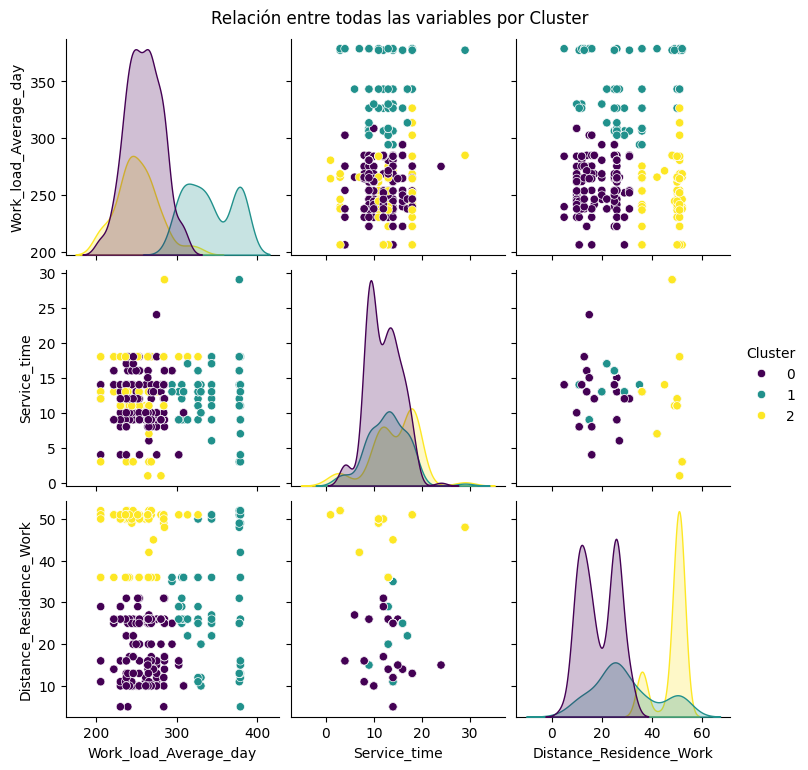

In [99]:
# Seleccionamos las variables y el cluster
variables_visualizar = ['Work_load_Average_day', 'Service_time', 'Distance_Residence_Work', 'Cluster']

sns.pairplot(df_empleados[variables_visualizar], hue='Cluster', palette='viridis')
plt.suptitle('Relación entre todas las variables por Cluster', y=1.02)
plt.show()